<a href="https://colab.research.google.com/github/nicolasDavalos/sis420_IA_Davalos_Alvarez_Nicolas_Darko/blob/main/regresion_logistica_lab03_davalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**modificacion de dataset para dividir un**a **texto en negrita** **columna**

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/gdrive/MyDrive/IA/prue_lab2/gaming_mental_health_10M_40features.csv", low_memory=False)

print(df.shape)

(1000000, 41)


In [ ]:
print(df.columns)

Index(['age', 'income', 'daily_gaming_hours', 'weekly_sessions',
       'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
       'stress_level', 'anxiety_score', 'depression_score',
       'social_interaction_score', 'relationship_satisfaction',
       'academic_performance', 'work_productivity', 'addiction_level',
       'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio',
       'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours',
       'friends_gaming_count', 'online_friends', 'streaming_hours',
       'esports_interest', 'headset_usage', 'microtransactions_spending',
       'parental_supervision', 'loneliness_score', 'aggression_score',
       'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score',
       'back_pain_score', 'competitive_rank', 'internet_quality',
       'gender_Female', 'gender_Male', 'gender_Other'],
      dtype='object')


el siguiente codigo devuelve los valores de la columna que se solicita (no volver a ejecutar)

In [ ]:
print(df["gender"].unique())

NameError: name 'df' is not defined

creara las nuevas columnas a partir la columna que se esta llamando dividiendola por sus valores y transformandolos a binario (no volver a ejecutar)

In [ ]:
df = pd.get_dummies(df, columns=["gender"])

veremos el cambio

In [ ]:
print(df.shape)

nuevas columnas

In [ ]:
print(df.columns)

guardar el dataset nuevo (no volver a ejecutar)

In [ ]:
df.to_csv("/content/gdrive/MyDrive/IA/prue_lab2/gaming_mental_health_10M_40features.csv", index=False)

**REGRESION** **LOGISTICA**

importacion de librerias

In [ ]:
# se utiliza para el manejo de rutas y directorios.
import os

#libreria de pandas
import pandas as pd

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

se cargan los datos del dataset, para las variables independientes y dependiente, tambien se modifica la dependiente para que de valores de binarios, ahora tambien dividiremos las filas del dataset para que el 80% sean para el entrenamiento y el 20% para pruebas

In [ ]:
df = pd.read_csv("/content/gdrive/MyDrive/IA/prue_lab2/gaming_mental_health_10M_40features.csv")

X = df.drop("addiction_level", axis=1)
y = (df["addiction_level"] >= 3).astype(int)

print(X.shape)
print(y.shape)

# convertir a numpy
X = X.values
y = y.values

# dividir datos 80% entrenamiento - 20% prueba
indices = np.random.permutation(X.shape[0])

split = int(0.8 * X.shape[0])

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

(1000000, 40)
(1000000,)
Datos entrenamiento: (800000, 40)
Datos prueba: (200000, 40)


ahora aplicaremos la funcion de sigmoid para que los numeros reales a un valor que se encuntre entre 0 - 1, ademas crea una matriz de ceros del mismo tamaño para luego cargar la funcion ahi

In [ ]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

preuba para ver si la funcion sigmoid esta bien (la misma que en ejemplo)

In [ ]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


**funcion de costo y gradiente**

aqui se prepara la la regrecion logistica, se obtienen las dimenciones de la matriz, aumentamos la columna de 1,

In [ ]:
# agregar columna de 1s para el intercepto

m_train = X_train.shape[0]
X_train = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)

m_test = X_test.shape[0]
X_test = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

usaremos la funcion de costo, veremos que tan bien o mal eta el modelo


In [ ]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

ahora entrenaremos al modelo con el algoritmo de descenso por gradiente su objetivo es minimizar theta para disminuir el costo, esto lo hace con cada iteraccion

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

aqui determinamos los "valores de aprendizaje" apara el modelo como el numero de iteracciones y alpha, ademas muestra un driagrama de como va el descenso por gradiente al aplicarlo, usa un ejemple con los datos tenidos de la primer fila del dataset para predecirlo

theta calculado: [-3.53262326e-01 -4.91491322e-03  1.02619046e-03  3.16136648e+00
  5.75171006e-03  6.67267467e-03  1.57125681e-04  6.32423560e-03
 -1.40608926e-03  9.25364214e-04 -1.58098382e-03  7.60489251e-03
 -2.02484748e-03 -8.74574564e-04 -8.23777534e-04  5.09467575e-03
  3.01110486e-03  7.62973430e-05 -2.18022391e-03 -2.24000477e-03
 -8.79347640e-03  7.84576662e-04 -3.08050076e-03  2.44966878e-03
 -5.18789711e-04 -6.93371475e-03 -3.34970604e-03  4.39792860e-03
 -5.02188570e-03 -2.59101600e-03  2.11280802e-03  2.79053810e-03
  4.12622642e-03  1.12196854e-01  1.05665367e-03 -5.92878671e-03
  8.07953739e-04 -2.25460174e-05 -2.60926173e-04  1.98039208e-03
 -4.39141729e-03]
Precisión final entrenamiento: 85.7145 %
Probabilidad de adicción: 0.03144241754505127
Predicción de clase: False


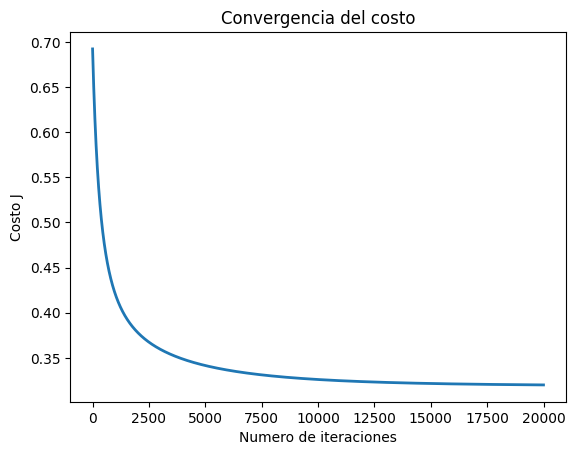

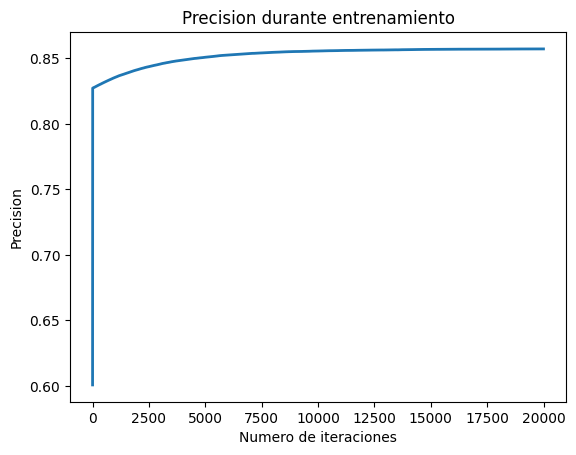

In [ ]:
# convertir a float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# NORMALIZAR VARIABLES (excepto intercepto)
mean = X_train[:,1:].mean(axis=0)
std = X_train[:,1:].std(axis=0)

X_train[:,1:] = (X_train[:,1:] - mean) / std
X_test[:,1:] = (X_test[:,1:] - mean) / std


# parametros del descenso por gradiente
alpha = 0.005
num_iters = 20000

# inicializar theta
theta = np.zeros(X_train.shape[1])

# ejecutar descenso por gradiente SOLO con entrenamiento
theta, J_history, P_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)


# grafica de convergencia del costo
pyplot.figure()
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')


# grafica de la precision
pyplot.figure()
pyplot.plot(np.arange(len(P_history)), P_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision')
pyplot.title('Precision durante entrenamiento')


print('theta calculado:', theta)

print("Precisión final entrenamiento:", P_history[-1] * 100, "%")


# probar con un ejemplo del TRAIN
ejemplo = X_train[0]

pred = sigmoid(np.dot(ejemplo, theta))
print("Probabilidad de adicción:", pred)

pred_clase = pred >= 0.5
print("Predicción de clase:", pred_clase)

agregamos precision a la grafica

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):

    m = y.size

    J_history = []
    P_history = []

    for i in range(num_iters):

        # predicciones
        h = sigmoid(X.dot(theta))

        # gradiente
        grad = (1/m) * X.T.dot(h - y)

        # actualizar theta
        theta = theta - alpha * grad

        # calcular costo
        J = calcularCosto(theta, X, y)
        J_history.append(J)

        # calcular precision
        pred = h >= 0.5
        precision = np.mean(pred == y)

        P_history.append(precision)

    return theta, J_history, P_history

ejemplo

In [ ]:
ejemplo = X_train[10]

prob = sigmoid(np.dot(ejemplo, theta))

print("Probabilidad de adicción:", prob)

pred_clase = prob >= 0.5
print("Predicción:", pred_clase)

Probabilidad de adicción: 0.01223206498001491
Predicción: False


ahora calcula el el costo y gradiente

In [ ]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    # Predicciones del modelo
    h = sigmoid(X.dot(theta.T))

    # evitar log(0)
    h = np.clip(h, 1e-10, 1 - 1e-10)

    # calcular costo
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    # calcular gradiente
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

calcula el costo inicial y gradiente inicial

In [ ]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [ ]:
initial_theta = np.zeros(X_train.shape[1])

print(initial_theta)

cost, grad = costFunction(initial_theta, X_train, y_train)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))

print('Gradiente inicial:')
print(grad[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Gradiente inicial:
[ 1.00747500e-01  1.12754431e-03 -4.85488091e-05 -3.40194612e-01
 -1.55173713e-03 -3.13145797e-04 -2.75444077e-04 -1.22198402e-03
  4.93110017e-05 -2.10519572e-04]


probar la función de costo

In [ ]:
# Crear theta de prueba con el tamaño correcto
test_theta = np.zeros(X_train.shape[1])

# asignar algunos valores de prueba
test_theta[0] = -24
test_theta[1] = 0.2
test_theta[2] = 0.2

print(test_theta)

cost, grad = costFunction(test_theta, X_train, y_train)

print('Costo en theta prueba: {:.3f}'.format(cost))

print('Primeros gradientes:')
print(grad[:10])

[-24.    0.2   0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   0.    0.    0.    0.    0. ]
Costo en theta prueba: 9.193
Primeros gradientes:
[-3.99252500e-01  1.12754431e-03 -4.85488091e-05 -3.40194612e-01
 -1.55173713e-03 -3.13145797e-04 -2.75444077e-04 -1.22198402e-03
  4.93110017e-05 -2.10519572e-04]


**Parámetros de aprendizaje usando scipy.optimize**

Este bloque entrena el modelo de regresión logística automáticamente usando optimización numérica de SciPy.

In [ ]:
# Establecer opciones para el optimizador
options = {'maxfun': 100}

# ejecutar optimización SOLO con entrenamiento
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

# obtener costo final
cost = res.fun

# obtener theta optimizado
theta = res.x

print('Costo con theta optimizado: {:.3f}'.format(cost))

print('Primeros valores de theta:')
print(theta[:10])

Costo con theta optimizado: 0.319
Primeros valores de theta:
[-3.41739252e-01 -5.08809627e-03  9.91663909e-04  3.50568950e+00
  5.81134883e-03  7.12721582e-03  1.73337967e-05  6.77097943e-03
 -1.71407074e-03  9.90362607e-04]


poder ver como el modelo separa las clases, tomando en cuenta solo dos de las 40 variables

In [ ]:
def plotDecisionBoundary(theta, X, y):

    theta = np.array(theta)

    # usar solo dos variables para graficar
    x1 = X[:,1]
    x2 = X[:,2]

    pos = y == 1
    neg = y == 0

    pyplot.figure()

    pyplot.scatter(x1[pos], x2[pos], marker='*', label='Clase 1')
    pyplot.scatter(x1[neg], x2[neg], marker='o', label='Clase 0')

    # rango de la grafica
    x1_range = np.linspace(np.min(x1), np.max(x1), 100)

    # promedio de las otras variables
    mean_features = np.mean(X[:,3:], axis=0)

    x2_vals = []

    for val in x1_range:

        # construir vector completo
        temp = np.zeros(X.shape[1])
        temp[0] = 1
        temp[1] = val
        temp[3:] = mean_features

        # despejar x2
        num = theta[0] + theta[1]*temp[1] + np.dot(theta[3:], mean_features)

        x2_val = -(num) / theta[2]

        x2_vals.append(x2_val)

    pyplot.plot(x1_range, x2_vals, label="Limite de decision")

    pyplot.xlabel("Variable 1")
    pyplot.ylabel("Variable 2")

    pyplot.legend()
    pyplot.title("Decision Boundary")

    pyplot.show()

empezamos con las predicciones

In [ ]:
def predict(theta, X):

    # calcular probabilidades
    prob = sigmoid(X.dot(theta.T))

    # aplicar umbral de 0.5
    p = prob >= 0.5

    return p.astype(int)

In [ ]:
# precisión en entrenamiento
p_train = predict(theta, X_train)

accuracy_train = np.mean(p_train == y_train) * 100

print('Precisión en entrenamiento: {:.2f} %'.format(accuracy_train))


# precisión en prueba
p_test = predict(theta, X_test)

accuracy_test = np.mean(p_test == y_test) * 100

print('Precisión en prueba: {:.2f} %'.format(accuracy_test))

Precisión en entrenamiento: 85.74 %
Precisión en prueba: 85.69 %


In [ ]:
# precisión en entrenamiento
p_train = predict(theta, X_train)
accuracy_train = np.mean(p_train == y_train) * 100
print("Precisión entrenamiento:", accuracy_train)

# precisión en prueba
p_test = predict(theta, X_test)
accuracy_test = np.mean(p_test == y_test) * 100
print("Precisión prueba:", accuracy_test)

Precisión entrenamiento: 85.735625
Precisión prueba: 85.693
